In [ ]:
import numpy as np
import pandas as pd
from plotnine import *
from scipy.stats import f
from sklearn.linear_model import LinearRegression

# Set the seed for reproducibility
np.random.seed(42)

In [2]:
# Function to generate synthetic data for simple linear regression
def generate_data(beta0, beta1, sigma, n):
    X = np.linspace(start=1, stop=n, num=n).reshape(-1, 1) #array w/ 1 column, the -1 means 'infer the # of rows'

    # Generate epsilon as a 1D array of N(0, sigma^2) RVs
    epsilon = sigma * np.random.randn(n)
    
    # Generate y using SLR model
    y = beta0 + beta1 * X.flatten() + epsilon

    return X, y 

In [3]:
# Simulate X and y data
X, y = generate_data(beta0 = 4, beta1 = 3, sigma =2, n = 100)

In [ ]:
# Function to perform sum of squares decomposition
# Calculates SST, SSR, SSE, R^2, and F-statistic, and generates plots to visualize the decomposition
# Returns the F-statistic value
def ss_decomp(X, y):

    # Fit a linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Make predictions
    y_pred = model.predict(X)

    # Calculate the mean of y
    y_mean = np.mean(y)
    n = len(y)

    # Calculate SS quantities
    SST = np.sum((y - y_mean) ** 2).round(4)
    SSR = np.sum((y_pred - y_mean) ** 2).round(4)
    SSE = np.sum((y - y_pred) ** 2).round(4)


    # Calculate the F-statistic
    Fstat = (SSR/1)/(SSE/(n-2))

    # Calculate the Coefficient of Determination, R^2
    R_squared = 1 - SSE/SST

    # Output the sum of squares decomposition
    print(f"SST (Total Sum of Squares): {SST}")
    print(f"SSR (Regression Sum of Squares): {SSR}")
    print(f"SSE (Error Sum of Squares): {SSE}")
    print(f"SST = SSR + SSE: {np.isclose(SST, SSR + SSE)}")
    
    print(f"Coefficient of Determination, R^2 is: {np.round(R_squared, 4)}")

    print(f"The F-test will reject the null hypothesis? {Fstat > f.ppf(0.95, dfn=1, dfd=n-2)}")

    
    #make a ggplot
    df = pd.DataFrame({
        'X': X.flatten(),
        'y': y,
        'predicted': y_pred,
        'y_mean':  y_mean
    })

    gg1 = (
        ggplot(df, aes(x = 'X', y = 'y')) + 
        geom_point() + 
        geom_hline(yintercept=y_mean, linetype='dashed') + 
        geom_segment(aes(xend = 'X', yend = 'y_mean'), color = "black") + #SST components
        ggtitle(f"R^2 is {np.round(1-SSE/SST, 4)}")
        )
    
    gg2 = (
        ggplot(df, aes(x = 'X', y = 'y')) + 
        geom_point() + 
        geom_smooth(method = "lm", formula = "y ~ x", se = False) +
        geom_hline(yintercept=y_mean, linetype='dashed') + 
        geom_segment(aes(xend = 'X', y = 'predicted', yend = 'y_mean'), color = "blue", linetype = "dashed") + #SSR components 
        geom_segment(aes(xend = 'X',  yend = 'predicted'), color = "red", linetype = "dashed") + #SSE components
        ggtitle(f"R^2 is {np.round(1-SSE/SST, 4)}")
        )

    display(gg1, gg2) #print the plots
    
    return Fstat 

SST (Total Sum of Squares): 770375.3707
SSR (Regression Sum of Squares): 760890.9182
SSE (Error Sum of Squares): 9484.4525
SST = SSR + SSE: True
Coefficient of Determination, R^2 is: 0.9877
The F-test will reject the null hypothesis? True


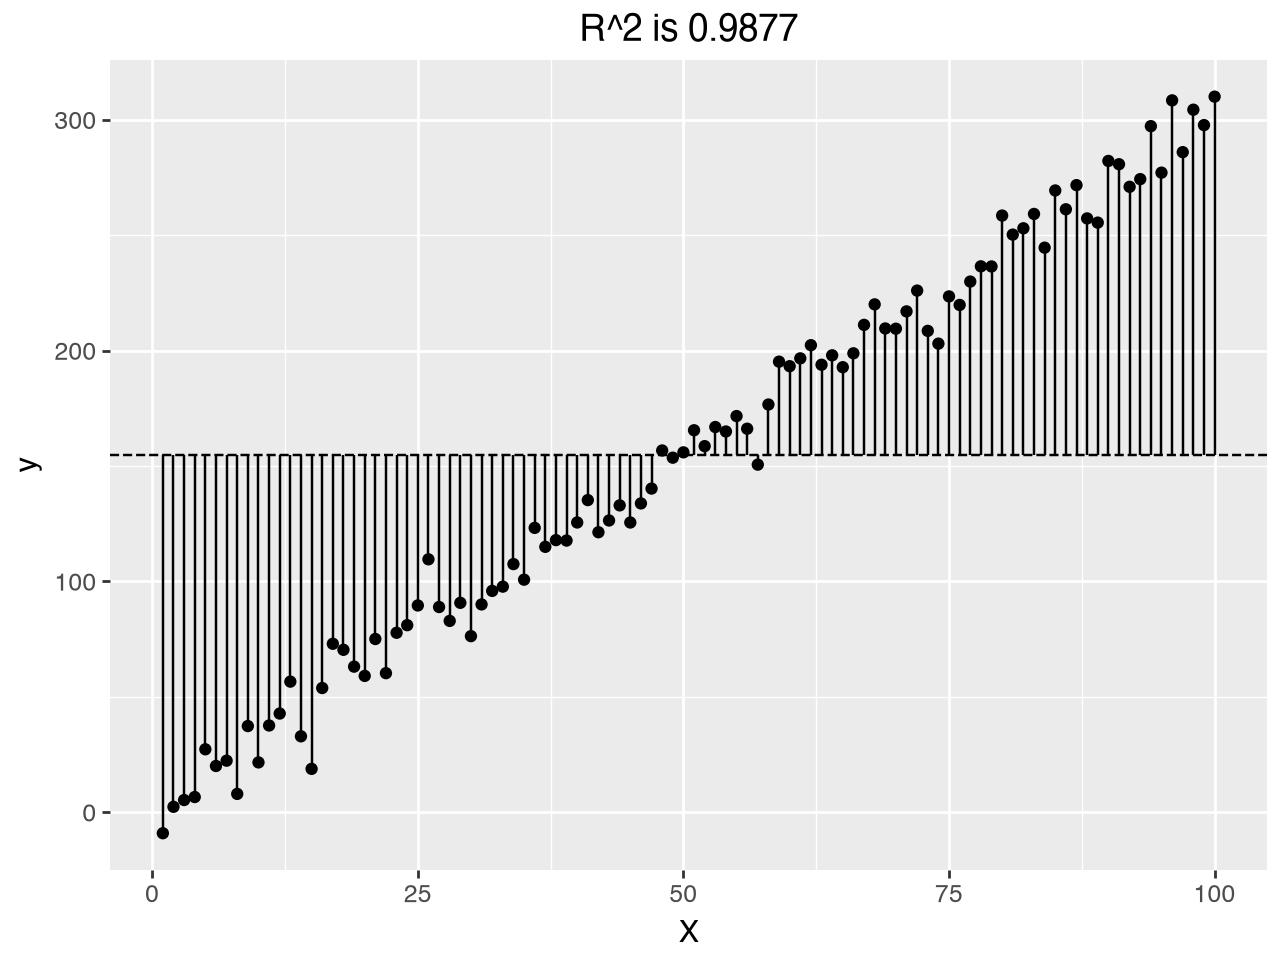

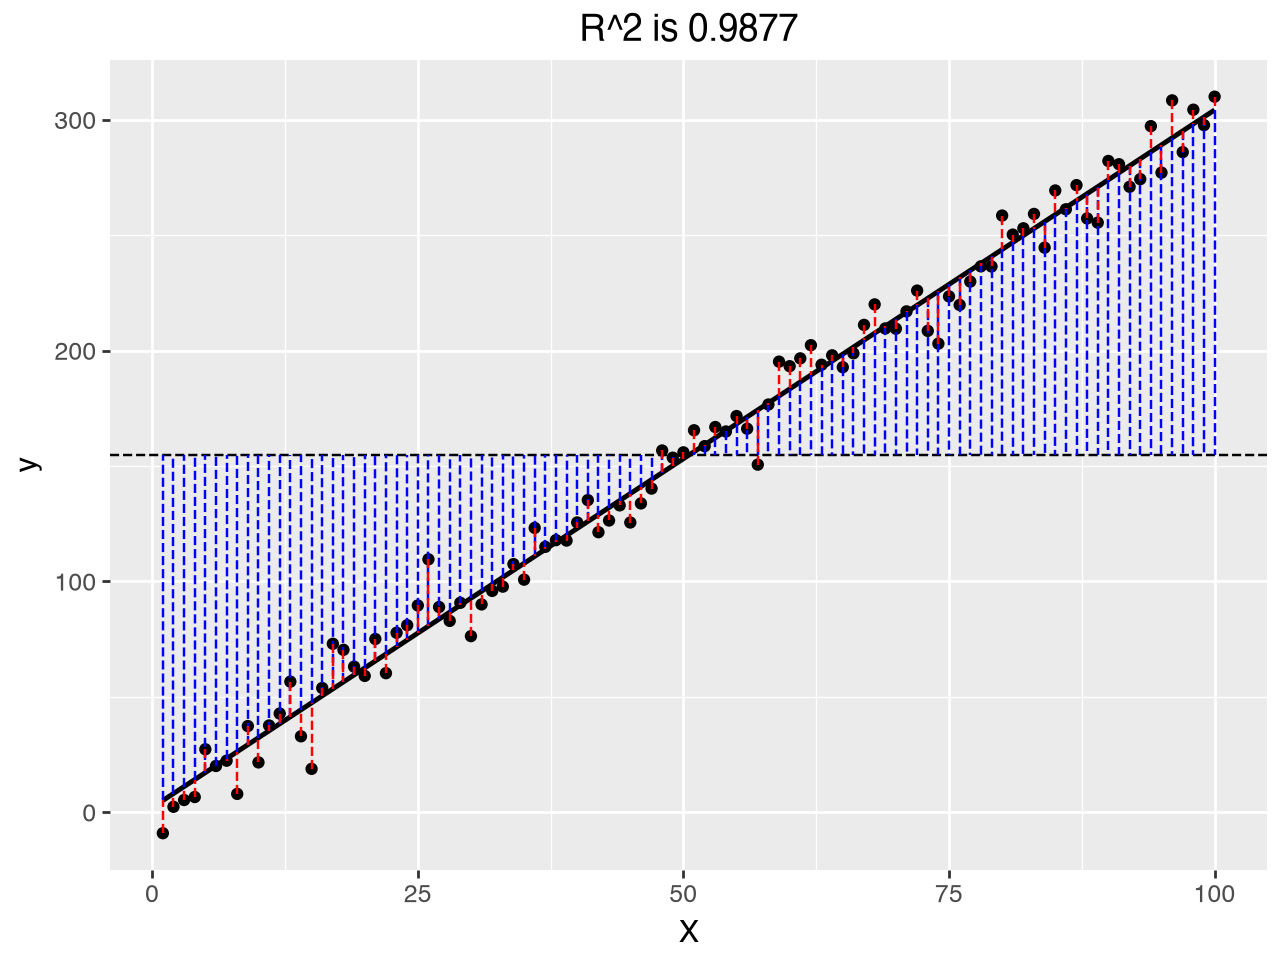

np.float64(7862.057402216944)

In [16]:
# Simulate new data and perform sum of squares decomposition
X, y = generate_data(beta0 = 4, beta1 = 3, sigma = 10, n = 100)
ss_decomp(X, y)


## Exercises:

1. Modify the SS decomposition function to calculate all of the sum or squares we need, and the coefficient of determination, $R^2$.
2. Modify the SS decomposition function to calculate the F statistic for the F-test.
4. Holding the intercept, sample size, and error variance constant, compare how different values of the slope affect:
   
    a.  the SS decomposition,\
    b. the plots,\
    c. the coefficient of determination, and\
    d. the hypothesis test results.\
   What do you find?
5. Holding the slope, sample size, and error variance constant, compare how different values of the intercept affect:\
    a.  the SS decomposition,\
    b. the plots,\
    c. the coefficient of determination, and\
    d. the hypothesis test results.\
   What do you find?
6. Holding the intercept, slope, and error variance constant, compare how different values of the sample size affect:\
    a.  the SS decomposition,\
    b. the plots,\
    c. the coefficient of determination, and\
    d. the hypothesis test results.\
   What do you find?
7. Write a function which calculates the t-statistic for testing whether the true slope is zero or not. For each simulation you run, calculate both the t-stat and the F-stat. Repeat this $B=100$ times, then plot the ordered pairs $\{(t_b, F_b)\}_{b=1}^B$ as a scatter plot. What relationship do you observe between them? Can you prove this relation?

In [ ]:
def t_stat_for_slope(beta0, betay, B=100):
    
    tstats = []
    Fstats = []
    for i in range(B):
        X, y = generate_data(beta0 = 4, beta1 = 3, sigma = 10, n = 100)

        # Fit a linear regression model
        model = LinearRegression()
        model.fit(X, y)

        # Make predictions
        y_pred = model.predict(X)

        # Calculate the mean of y
        y_mean = np.mean(y)
        n = len(y)

        # Calculate SS quantities
        # SST = np.sum((y - y_mean) ** 2).round(4)
        SSR = np.sum((y_pred - y_mean) ** 2).round(4)
        SSE = np.sum((y - y_pred) ** 2).round(4)

        # Calculate the t-statistic
        tstat = np.mean(X)/(SSE/np.sqrt(n))
        tstats.append(tstat)

        # Calculate the F-statistic
        Fstat = (SSR/1)/(SSE/(n-2))
        Fstats.append(Fstat)

    # make a ggplot
    df = pd.DataFrame({
        't': tstats,
        'F': Fstats
    })

    gg1 = (
        ggplot(df, aes(x = 'X', y = 'y')) + 
        geom_point() +
        ggtitle(f"tstat vs Fstat")
        )


    display(gg1)

In [ ]:
X, y = 
ss_decomp(X, y)